# Uber Fare Prediction

Let's Build a machine learning model to predict Uber ride fares.
We will do it step by step: loading data, cleaning, feature engineering, removing outliers, and training regression models.


## 1. Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 2. Loading the Dataset

In [3]:
df = pd.read_csv('uber.csv')

In [4]:
df.head()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         200000 non-null  int64  
 1   key                200000 non-null  str    
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  str    
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), str(2)
memory usage: 13.7 MB


In [6]:
df.describe()

,Unnamed: 0,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,2.000000e+05,200000.000000,200000.000000,200000.000000,199999.000000,199999.000000,200000.000000
mean,2.771250e+07,11.359955,-72.527638,39.935885,-72.525292,39.923890,1.684535
std,1.601382e+07,9.901776,11.437787,7.720539,13.117408,6.794829,1.385997
min,1.000000e+00,-52.000000,-1340.648410,-74.015515,-3356.666300,-881.985513,0.000000
25%,1.382535e+07,6.000000,-73.992065,40.734796,-73.991407,40.733823,1.000000
50%,2.774550e+07,8.500000,-73.981823,40.752592,-73.980093,40.753042,1.000000
75%,4.155530e+07,12.500000,-73.967154,40.767158,-73.963658,40.768001,2.000000
max,5.542357e+07,499.000000,57.418457,1644.421482,1153.572603,872.697628,208.000000


## 3. Data Cleaning

We drop columns that are not useful for prediction (`Unnamed: 0` and `key`), then remove rows with missing coordinate values.


In [7]:
df.drop(columns=['Unnamed: 0', 'key'], inplace=True)

In [8]:
# Check for missing values
df.isnull().sum()

fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    1
dropoff_latitude     1
passenger_count      0
dtype: int64

In [9]:
# Drop rows with missing coordinates 
df.dropna(subset=['pickup_longitude', 'pickup_latitude',
                  'dropoff_longitude', 'dropoff_latitude'], inplace=True)

df.isnull().sum()

fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    0
dropoff_latitude     0
passenger_count      0
dtype: int64

## 4. Feature Engineering

### 4.1 Distance (Haversine Formula)

Uber fares are primarily driven by distance. Since we have GPS coordinates, we use the **Haversine formula** to calculate the straight-line distance between pickup and dropoff points in kilometres.


In [10]:
def haversine(lat1, lng1, lat2, lng2):
    R = 6371  # Earth's radius in km

    # Convert degrees to radians
    lat1, lng1, lat2, lng2 = map(np.radians, [lat1, lng1, lat2, lng2])

    # Compute differences
    dlat = lat2 - lat1
    dlng = lng2 - lng1

    # Haversine formula
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlng/2)**2
    distance = 2 * R * np.arcsin(np.sqrt(a))

    return distance

In [11]:
df['distance_km'] = haversine(
    df['pickup_latitude'],
    df['pickup_longitude'],
    df['dropoff_latitude'],
    df['dropoff_longitude']
)

### 4.2 Datetime Features

We extract the hour, day of week, month, and year from the pickup datetime. These help capture time-based patterns like rush hour and weekends.


In [12]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'], utc=True)

df['hour']        = df['pickup_datetime'].dt.hour
df['day_of_week'] = df['pickup_datetime'].dt.dayofweek  # 0=Monday, 6=Sunday
df['month']       = df['pickup_datetime'].dt.month
df['year']        = df['pickup_datetime'].dt.year

### 4.3 Rush Hour, Night, and Weekend Flags

We create binary indicator columns to flag whether a ride happened during rush hour, at night, or on a weekend — these can affect fare pricing.


In [13]:
df['is_rush_hour'] = ((df['hour'].between(7, 9)) | (df['hour'].between(17, 19))).astype(int)
df['is_night']     = ((df['hour'] >= 20) | (df['hour'] <= 5)).astype(int)
df['is_weekend']   = (df['day_of_week'] >= 5).astype(int)

# Quick check
df[['pickup_datetime', 'hour', 'is_rush_hour', 'is_weekend']].sample(10)

,pickup_datetime,hour,is_rush_hour,is_weekend
15553,2010-10-17 14:12:00+00:00,14,0,1
167672,2011-02-14 14:06:34+00:00,14,0,0
25950,2009-11-15 08:56:00+00:00,8,1,1
122288,2014-03-21 16:16:49+00:00,16,0,0
151224,2012-09-07 00:33:31+00:00,0,0,0
171914,2014-09-26 20:59:50+00:00,20,0,0
99527,2013-10-16 07:12:13+00:00,7,1,0
144978,2014-05-10 20:08:00+00:00,20,0,1
146701,2012-02-23 23:37:25+00:00,23,0,0
82326,2013-05-21 12:15:35+00:00,12,0,0


## 5. Removing Outliers

Before modelling, we remove unrealistic values that could skew our model.


### 5.1 Passenger Count

In [14]:
# Keep only rides with 1–6 passengers (standard Uber capacity)
df = df[df['passenger_count'].between(1, 6)]
print(df.shape)

(199290, 15)


### 5.2 Distance Outliers

In [15]:
print(df['distance_km'].quantile([0.90, 0.95, 0.99, 0.999]))


0.900       7.025261
0.950      10.115423
0.990      20.722438
0.999    8665.363388
Name: distance_km, dtype: float64


In [16]:
upper = df['distance_km'].quantile(0.99)
df = df[df['distance_km'].between(0.1, upper)]
print('Shape after distance filter:', df.shape)

Shape after distance filter: (190516, 15)


### 5.3 Fare Amount Outliers

In [17]:
# Check where 99% of fares fall
print('99th percentile fare:', df['fare_amount'].quantile(0.99))


99th percentile fare: 49.57


In [18]:
# A fare below $2.50 is below Uber's minimum; above $100 is likely an outlier
df = df[df['fare_amount'].between(2.5, 100)]
print('Final shape:', df.shape)
df[['fare_amount', 'passenger_count', 'distance_km']].describe()

Final shape: (190481, 15)


,fare_amount,passenger_count,distance_km
count,190481.000000,190481.000000,190481.000000
mean,10.970108,1.690463,3.221850
std,8.529790,1.306556,3.183254
min,2.500000,1.000000,0.100227
25%,6.000000,1.000000,1.288360
50%,8.500000,1.000000,2.176343
75%,12.500000,2.000000,3.887369
max,99.000000,6.000000,20.722387


## 6. Exploratory Visualization

A quick look at the relationship between distance and fare, and the distribution of distances after cleaning.


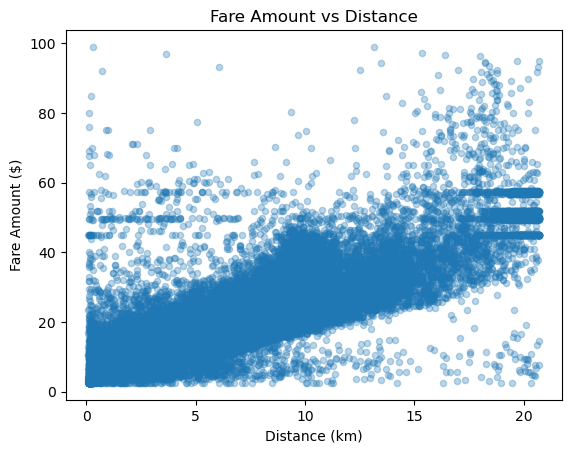

In [19]:
# Fare vs Distance
df.plot.scatter(x='distance_km', y='fare_amount', alpha=0.3)
plt.title('Fare Amount vs Distance')
plt.xlabel('Distance (km)')
plt.ylabel('Fare Amount ($)')
plt.show()

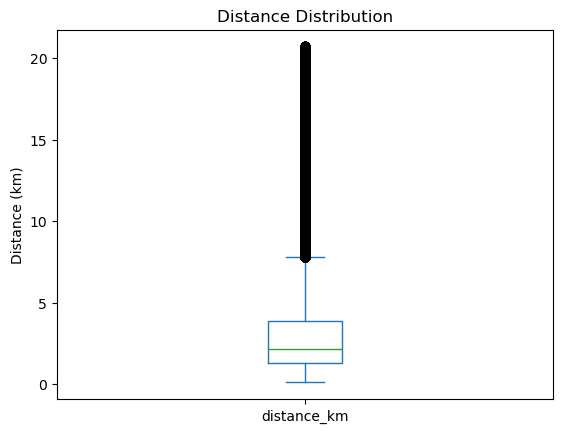

In [20]:
# Distance distribution (boxplot)
df['distance_km'].plot(kind='box')
plt.title('Distance Distribution')
plt.ylabel('Distance (km)')
plt.show()

## 7. Preparing Data for Modelling

We select the features that will be used by our models and split the data into training and test sets (80/20 split).


In [21]:
X = df[['distance_km', 'passenger_count', 'hour',
        'day_of_week', 'month', 'year',
        'is_rush_hour', 'is_weekend', 'is_night']]

y = df['fare_amount']

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Training samples:', X_train.shape[0])
print('Test samples:    ', X_test.shape[0])

Training samples: 152384
Test samples:     38097


## 8. Model 1: Linear Regression

We start with Linear Regression as our baseline model. It's simple and interpretable, but assumes a linear relationship between features and fare.


In [23]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr  = mean_absolute_error(y_test, y_pred_lr)
r2_lr   = r2_score(y_test, y_pred_lr)

print(f'RMSE : {rmse_lr:.2f}')
print(f'MAE  : {mae_lr:.2f}')
print(f'R²   : {r2_lr:.4f}')

RMSE : 3.74
MAE  : 2.12
R²   : 0.8077


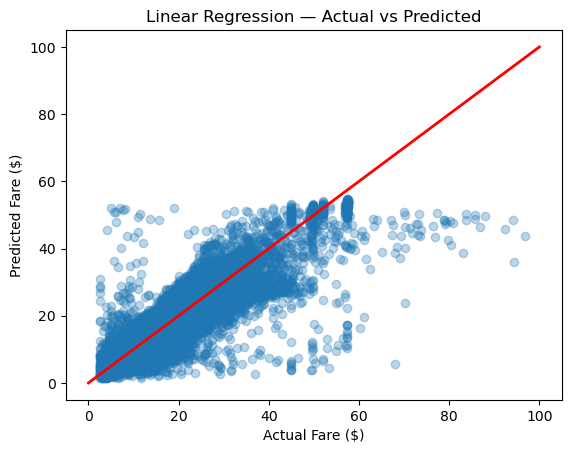

In [24]:
# Actual vs Predicted plot
plt.scatter(y_test, y_pred_lr, alpha=0.3)
plt.plot([0, 100], [0, 100], color='red', linewidth=2)
plt.xlabel('Actual Fare ($)')
plt.ylabel('Predicted Fare ($)')
plt.title('Linear Regression — Actual vs Predicted')
plt.show()

> **Note:** Linear Regression performs reasonably but struggles with high fares. That's because it assumes fare increases *perfectly proportionally* with distance. Real-world fares are influenced by non-linear factors like airport surcharges, traffic, and time of day — which Linear Regression cannot capture.


## 9. Model 2: Random Forest

Random Forest is an ensemble of decision trees. It handles non-linear relationships much better than Linear Regression.


In [25]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
r2_rf   = r2_score(y_test, y_pred_rf)

print(f'RMSE : {rmse_rf:.2f}')
print(f'MAE  : {mae_rf:.2f}')
print(f'R²   : {r2_rf:.4f}')

RMSE : 3.66
MAE  : 2.06
R²   : 0.8156


## 10. Model 3: Gradient Boosting

Gradient Boosting builds trees sequentially, where each tree corrects the errors of the previous one. It often outperforms Random Forest on structured/tabular data.


In [26]:
gb_model = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, random_state=42)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
mae_gb  = mean_absolute_error(y_test, y_pred_gb)
r2_gb   = r2_score(y_test, y_pred_gb)

print(f'RMSE : {rmse_gb:.2f}')
print(f'MAE  : {mae_gb:.2f}')
print(f'R²   : {r2_gb:.4f}')

RMSE : 3.50
MAE  : 1.92
R²   : 0.8319


## 11. Model Comparison

We compare all three models side by side using RMSE, MAE, and R² to pick the best one.


In [27]:
results = {
    'Linear Regression': [rmse_lr, mae_lr, r2_lr],
    'Random Forest':     [rmse_rf, mae_rf, r2_rf],
    'Gradient Boosting': [rmse_gb, mae_gb, r2_gb]
}

results_df = pd.DataFrame(results, index=['RMSE', 'MAE', 'R²'])
results_df

,Linear Regression,Random Forest,Gradient Boosting
RMSE,3.740948,3.663980,3.497915
MAE,2.116794,2.061350,1.918551
R²,0.807723,0.815554,0.831895


## 12. Feature Importance (Gradient Boosting)

We look at which features the Gradient Boosting model found most useful for predicting fare.


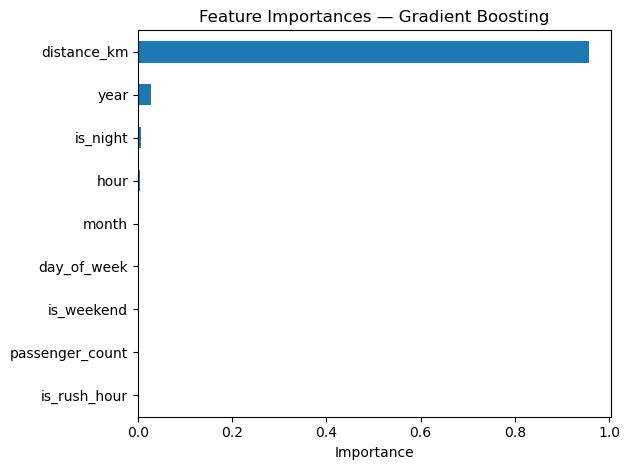

In [28]:
importances = pd.Series(gb_model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh')
plt.title('Feature Importances — Gradient Boosting')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## 13. Saving the Best Model

We save the Gradient Boosting model to disk using `joblib` so it can be reused later without retraining.


In [ ]:
joblib.dump(gb_model, 'best_model.pkl')
print('Model saved as best_model.pkl')

## 14. Conclusion

We built and compared three regression models to predict Uber fares:

- **Linear Regression** — fast and interpretable, but limited by its linear assumptions
- **Random Forest** — handles non-linearity well with good accuracy
- **Gradient Boosting** — best overall performance, capturing complex patterns in the data

The most important predictor was `distance_km`, followed by time-based features like `hour` and `year`. The binary flags (`is_rush_hour`, `is_weekend`, `is_night`) also contributed, confirming that fare pricing is influenced by when a ride takes place.
